In [20]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from utils import add_temp_errors, extract_digits_from_answers, merge_with_indomain_year_only
from prediction_analysis import calc_final_scores

In [2]:
llama = pd.read_csv(
    "./../../models/predictions/Llama/fewshot_with_reasoning/outdomain_eval_llama2_few_shot_with_reasoning.csv"
).drop(columns="Unnamed: 0")
llama.shape

(820, 4)

In [3]:
llama.head()

,table,question,actual_answer,predicted_answer
0,2,How many years did Art Carney as actor since 1...,54 Years,Answer: 54 years\n\nReasoning: Art Carney beg...
1,2,Who was the spouse of Art Carney in 1970?,Barbara Isaac,"Answer: Barbara Isaac\n\nReasoning: In 1970, ..."
2,2,How many total years was Art Carney married to...,28 years,Answer: 25 years\n\nReasoning: Art Carney was...
3,2,Which spouse was Art Carney married to the least?,Barbara Isaac,"The answer to the question ""Which spouse was ..."
4,2,Who was Art Carney married to when he served i...,Jean Myers,Answer: Jean Myers\n\nReasoning: Art Carney wa...


In [4]:
temp_err_df = merge_with_indomain_year_only(llama)
temp_err_df.head()

,question,answer,table_id,predicted_answer
0,How many years did Art Carney as actor since 1...,54 Years,2,Answer: 54 years\n\nReasoning: Art Carney beg...
1,How many total years was Art Carney married to...,28 years,2,Answer: 25 years\n\nReasoning: Art Carney was...
2,How many years before he died was Art Carney m...,23,2,Answer: 17 years\n\nReasoning: Art Carney die...
3,How old was Art Carney when he first got divor...,47,2,Answer: 47 years old\n\nReasoning: Art Carney ...
4,How many years ago did Art Carney was died?,19 Years ago,2,Answer: 19 years ago\n\nReasoning: Art Carney...


In [5]:
temp_err_df = extract_digits_from_answers(temp_err_df, split_str_reas="\n\n")
temp_err_df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,Answer: 54 years,Answer: 54 years\n\nReasoning: Art Carney beg...,Answer: 54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,Answer: 25 years,Answer: 25 years\n\nReasoning: Art Carney was...,Answer: 25 years,[28],[25]
2,How many years before he died was Art Carney m...,23,2,Answer: 17 years,Answer: 17 years\n\nReasoning: Art Carney die...,Answer: 17 years,[23],[17]
3,How old was Art Carney when he first got divor...,47,2,Answer: 47 years old,Answer: 47 years old\n\nReasoning: Art Carney ...,Answer: 47 years old,[47],[47]
4,How many years ago did Art Carney was died?,19 Years ago,2,Answer: 19 years ago,Answer: 19 years ago\n\nReasoning: Art Carney...,Answer: 19 years ago,[19],[19]


In [6]:
temp_err_single_digit_df = temp_err_df.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
)
temp_err_single_digit_df.shape

(308, 8)

In [7]:
temp_err_single_digit_df = add_temp_errors(temp_err_single_digit_df)
temp_err_single_digit_df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
0,How many years did Art Carney as actor since 1...,54 Years,2,Answer: 54 years,Answer: 54 years\n\nReasoning: Art Carney beg...,Answer: 54 years,54,54,0,0.000000,0,0.000000,0.000000
1,How many total years was Art Carney married to...,28 years,2,Answer: 25 years,Answer: 25 years\n\nReasoning: Art Carney was...,Answer: 25 years,28,25,-3,-0.107143,3,10.714286,-0.109199
2,How many years before he died was Art Carney m...,23,2,Answer: 17 years,Answer: 17 years\n\nReasoning: Art Carney die...,Answer: 17 years,23,17,-6,-0.260870,6,26.086957,-0.287682
3,How old was Art Carney when he first got divor...,47,2,Answer: 47 years old,Answer: 47 years old\n\nReasoning: Art Carney ...,Answer: 47 years old,47,47,0,0.000000,0,0.000000,0.000000
4,How many years ago did Art Carney was died?,19 Years ago,2,Answer: 19 years ago,Answer: 19 years ago\n\nReasoning: Art Carney...,Answer: 19 years ago,19,19,0,0.000000,0,0.000000,0.000000


In [8]:
temp_err_single_digit_df.query("rel_err!=rel_err")

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
150,How many years after Rudolf Thienel became Pre...,0,254,Answer: 0 years,Answer: 0 years\n\nReasoning: Anna Sporrer be...,Answer: 0 years,0,0,0,NaN,0,NaN,0.0


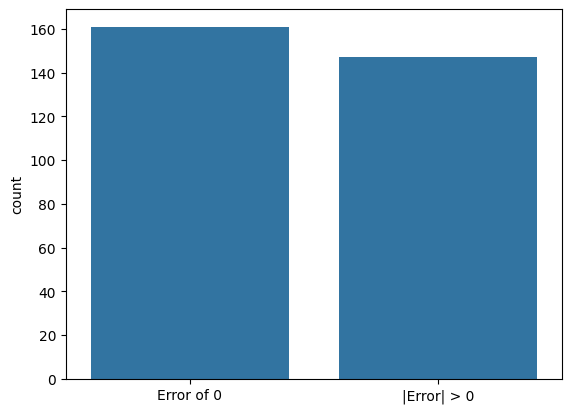

In [9]:
ax = sns.countplot(x=np.where(temp_err_single_digit_df["err"] == 0, "Error of 0", "|Error| > 0"))

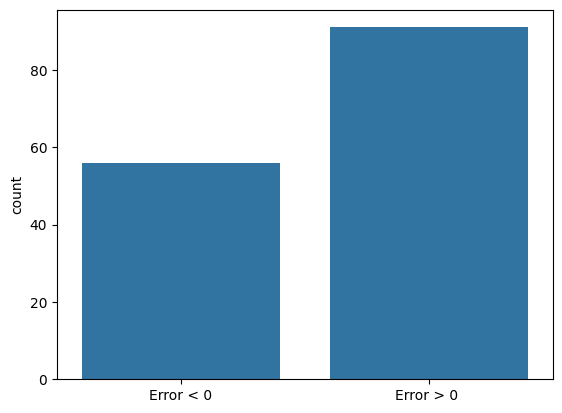

In [10]:
ax = sns.countplot(
    x=np.where(temp_err_single_digit_df.query("err!=0")["err"] > 0, "Error > 0 ", "Error < 0")
)

<Axes: ylabel='rel_err'>

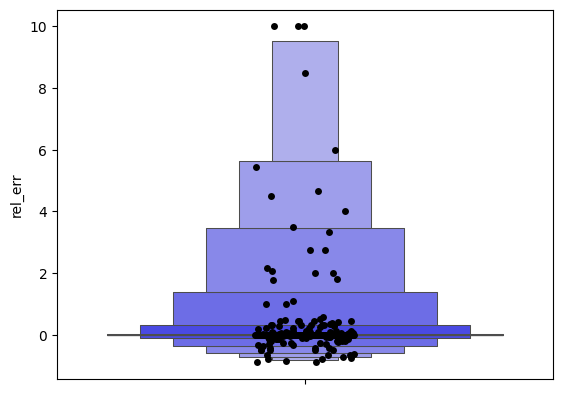

In [11]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs() < 100"),
    y="rel_err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<200"), y="rel_err", color="k", ax=ax)

In [12]:
temp_err_single_digit_df.loc[:, "err"].value_counts().iloc[:10]

err
 0     161
 1      24
-1      17
 2      10
 10      8
-4       7
 3       6
-3       6
 4       5
-10      5
Name: count, dtype: int64

In [13]:
temp_err_single_digit_df.loc[:, "abs_err"].value_counts().iloc[:10]

abs_err
0     161
1      41
2      15
10     13
3      12
4      12
5       8
8       6
14      4
7       4
Name: count, dtype: int64

In [14]:
temp_err_single_digit_df.query("abs_err > 100").loc[:, "abs_err"]

33     2017
40     1964
145    1876
155    1954
319     102
320     249
336    1905
382    2013
Name: abs_err, dtype: int64

In [15]:
rel_error = temp_err_single_digit_df.rel_err
rel_error = rel_error[np.isfinite(rel_error)]
err = temp_err_single_digit_df.err
abs_err = temp_err_single_digit_df.abs_err


print(f"Mean error in years: {np.mean(err).round(2)} ± {np.std(err).round(2)}")
print(f"Mean |error| in years: {np.mean(abs_err).round(2)} ± {np.std(abs_err).round(2)}")
print(f"Mean rel. error: {np.mean(rel_error).round(2)} ± {np.std(rel_error).round(2)}")
print(f"Mean rel. error, where error > 0: {np.mean(rel_error[rel_error > 0]).round(2)} ± {np.std(rel_error[rel_error > 0]).round(2)}")
print(f"Mean rel. error, where error < 0: {np.mean(rel_error[rel_error < 0]).round(2)} ± {np.std(rel_error[rel_error < 0]).round(2)}")

Mean error in years: 27.46 ± 272.09
Mean |error| in years: 42.27 ± 270.18
Mean rel. error: 13.53 ± 139.93
Mean rel. error, where error > 0: 46.21 ± 255.06
Mean rel. error, where error < 0: -0.32 ± 0.28


In [16]:
calc_final_scores(temp_err_single_digit_df.rename(columns={"answer": "actual_answer", "predicted_answer": "predicted_answer_new", "predicted_answer_old": "predicted_answer"}))

{'f1': 57.85346187001275,
 'EM': 56.16883116883117,
 'ROUGE1': 0.5782091597383124,
 'ROUGE2': 0.578091095983885,
 'METERO': 0.42325700106423597}

In [17]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.mean()

1365.0243724622267

In [18]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.quantile(0.90)

86.11111111111111

In [19]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.median()

0.0